# EDA — HRV Cohort (processed data)

**Goal:** derive the H1–H10 HRV characteristics directly from the processed cohort (pre-smoothing) and build a global summary used as proof.

**Input:** `data/processed/*_processed.csv` (columns: createdTime, hrvValue, minute_diff).

**Outputs:** `notebooks/outputs/hrv_characteristics_summary.csv` (per patient) and `notebooks/outputs/h1_h10_global.csv` / `.md` (cohort verdicts).

In [1]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy.stats as sps
from scipy.signal import welch
from pathlib import Path

try:
    from statsmodels.tsa.stattools import adfuller
    HAS_SM = True
except ImportError:
    HAS_SM = False

try:
    from sklearn.mixture import GaussianMixture
    HAS_SK = True
except ImportError:
    HAS_SK = False

np.random.seed(42)
DT_MIN = 10.0
LAGS_DAY = 144

REPO_ROOT = Path.cwd().resolve()
if REPO_ROOT.name == 'notebooks':
    REPO_ROOT = REPO_ROOT.parent
PROCESSED_DIR = REPO_ROOT / 'data' / 'processed'
OUT_DIR = REPO_ROOT / 'notebooks' / 'outputs'
OUT_DIR.mkdir(parents=True, exist_ok=True)

%matplotlib inline
print('statsmodels:', HAS_SM, '| sklearn:', HAS_SK)
print('REPO_ROOT:', REPO_ROOT)

statsmodels: True | sklearn: True
REPO_ROOT: /Users/jatindangi/Desktop/asthma-project-research/asthma-prediction


## 1. Load cohort

In [2]:
files = sorted(PROCESSED_DIR.glob('*_processed.csv'))
if not files:
    raise FileNotFoundError('No *_processed.csv under ' + str(PROCESSED_DIR) + '. Run: python src/00_preprocess_raw.py')
print(len(files), 'processed patient files')

109 processed patient files


## 2. Per-patient HRV characteristics

Each characteristic is computed on the raw `hrvValue` series (NaN gap-fill rows excluded).

In [3]:
def characteristics(df, pid):
    df = df.copy()
    df['createdTime'] = pd.to_datetime(df['createdTime'])
    s = df['hrvValue'].dropna().values.astype(float)
    n = len(s)
    d = {'patient': pid, 'n_total': len(df), 'n_valid': n}
    if n < 10:
        return d

    d['mean'] = float(np.mean(s))
    d['std'] = float(np.std(s))
    d['median'] = float(np.median(s))
    d['iqr'] = float(np.percentile(s, 75) - np.percentile(s, 25))
    d['skew'] = float(sps.skew(s))
    d['kurtosis_excess'] = float(sps.kurtosis(s))

    # H1 bounded positive
    d['h1_all_positive'] = bool(np.all(s > 0))
    d['h1_n_nonpositive'] = int(np.sum(s <= 0))
    d['h1_n_above_300'] = int(np.sum(s > 300))

    # H2 bimodality
    sk, ku = d['skew'], d['kurtosis_excess']
    denom = ku + 3 * (n - 1) ** 2 / ((n - 2) * (n - 3)) + 3
    d['h2_bimodality_coeff'] = float((sk ** 2 + 1) / denom) if denom else np.nan
    if HAS_SK and n > 20:
        X = s.reshape(-1, 1)
        g1 = GaussianMixture(1, random_state=42).fit(X)
        g2 = GaussianMixture(2, random_state=42).fit(X)
        d['h2_gmm_delta_bic'] = float(g1.bic(X) - g2.bic(X))

    # H3 + H5 spectral
    if n > 200:
        nperseg = min(n // 4, LAGS_DAY * 2)
        f, psd = welch(s, fs=1.0 / DT_MIN, nperseg=nperseg)
        pos = f > 0
        d['h3_spectral_slope'] = float(sps.linregress(np.log10(f[pos]), np.log10(psd[pos])).slope)
        period_h = np.where(pos, 1.0 / (f * 60.0), np.inf)
        tot = psd[pos].sum()
        circ = (period_h >= 20) & (period_h <= 28) & pos
        semi = (period_h >= 9) & (period_h <= 14) & pos
        d['h3_pct_power_circadian'] = float(psd[circ].sum() / tot * 100) if circ.any() else 0.0
        d['h3_pct_power_semidiurnal'] = float(psd[semi].sum() / tot * 100) if semi.any() else 0.0

    # H4 stationarity
    if HAS_SM and n > 50:
        try:
            d['h4_adf_pvalue'] = float(adfuller(s, autolag='AIC')[1])
        except Exception:
            pass
    rstd = pd.Series(s).rolling(LAGS_DAY, min_periods=1).std().dropna()
    if len(rstd) and rstd.mean() > 0:
        d['h4_rolling_std_cv'] = float(rstd.std() / rstd.mean())

    # H6 within-segment first-difference noise
    dv = df[['createdTime', 'hrvValue']].dropna(subset=['hrvValue'])
    gap = dv['createdTime'].diff().dt.total_seconds() / 60.0
    within = (gap <= 15.0).values
    diffs = np.diff(dv['hrvValue'].values)[within[1:]]
    if len(diffs):
        d['h6_diff_kurt'] = float(sps.kurtosis(diffs))
        d['h6_sigma_x_mad'] = float(1.4826 * np.median(np.abs(diffs)) / np.sqrt(2))

    # H7 sampling regularity
    td = df['minute_diff'].dropna()
    if len(td):
        d['h7_median_step_min'] = float(td.median())
        d['h7_pct_10min_steps'] = float(((td - 10.0).abs() < 0.5).mean() * 100)

    # H8 missingness
    d['h8_nan_pct'] = float(df['hrvValue'].isna().mean() * 100)
    return d

rows = []
for fp in files:
    pid = fp.stem.replace('_processed', '')
    rows.append(characteristics(pd.read_csv(fp), pid))
summary = pd.DataFrame(rows)
summary.to_csv(OUT_DIR / 'hrv_characteristics_summary.csv', index=False)
print('summary shape:', summary.shape)
summary.head()

/var/folders/xp/4m6w382n6d1b6lj335yymgk40000gn/T/ipykernel_18926/2364710651.py:38: RuntimeWarning: divide by zero encountered in divide
  period_h = np.where(pos, 1.0 / (f * 60.0), np.inf)


/var/folders/xp/4m6w382n6d1b6lj335yymgk40000gn/T/ipykernel_18926/2364710651.py:38: RuntimeWarning: divide by zero encountered in divide
  period_h = np.where(pos, 1.0 / (f * 60.0), np.inf)


/var/folders/xp/4m6w382n6d1b6lj335yymgk40000gn/T/ipykernel_18926/2364710651.py:38: RuntimeWarning: divide by zero encountered in divide
  period_h = np.where(pos, 1.0 / (f * 60.0), np.inf)


/var/folders/xp/4m6w382n6d1b6lj335yymgk40000gn/T/ipykernel_18926/2364710651.py:38: RuntimeWarning: divide by zero encountered in divide
  period_h = np.where(pos, 1.0 / (f * 60.0), np.inf)


/var/folders/xp/4m6w382n6d1b6lj335yymgk40000gn/T/ipykernel_18926/2364710651.py:38: RuntimeWarning: divide by zero encountered in divide
  period_h = np.where(pos, 1.0 / (f * 60.0), np.inf)


...

/var/folders/xp/4m6w382n6d1b6lj335yymgk40000gn/T/ipykernel_18926/2364710651.py:38: RuntimeWarning: divide by zero encountered in divide
  period_h = np.where(pos, 1.0 / (f * 60.0), np.inf)


/var/folders/xp/4m6w382n6d1b6lj335yymgk40000gn/T/ipykernel_18926/2364710651.py:38: RuntimeWarning: divide by zero encountered in divide
  period_h = np.where(pos, 1.0 / (f * 60.0), np.inf)


summary shape: (109, 24)


/var/folders/xp/4m6w382n6d1b6lj335yymgk40000gn/T/ipykernel_18926/2364710651.py:38: RuntimeWarning: divide by zero encountered in divide
  period_h = np.where(pos, 1.0 / (f * 60.0), np.inf)


,patient,n_total,n_valid,mean,std,median,iqr,skew,kurtosis_excess,h1_all_positive,...,h3_spectral_slope,h3_pct_power_circadian,h3_pct_power_semidiurnal,h4_adf_pvalue,h4_rolling_std_cv,h6_diff_kurt,h6_sigma_x_mad,h7_median_step_min,h7_pct_10min_steps,h8_nan_pct
0,0010,24464,12580,95.281717,35.684454,116.0,60.0,-0.773109,-1.006379,True,...,-0.734578,8.121501,11.700777,0.000000e+00,0.127029,1.742676,9.435209,10.0,95.744594,48.577502
1,005,27925,8978,89.360659,30.182282,90.0,57.0,-0.237511,-1.238272,True,...,-0.499459,5.004311,5.057525,2.042476e-30,0.125062,0.410583,17.822061,10.0,98.112735,67.849597
2,008,18897,5611,95.350918,30.285018,101.0,50.0,-0.640179,-0.756381,True,...,-0.627289,8.010985,7.285824,1.140065e-19,0.177356,1.639041,11.531922,10.0,96.708298,70.307456
3,019,26812,9952,83.214731,23.821647,81.0,30.0,0.073568,-0.321745,True,...,-0.483644,5.522915,5.071972,4.178429e-28,0.178085,0.698652,16.773704,10.0,98.560292,62.882292
4,020,8764,5885,83.664401,35.964233,84.0,75.0,-0.095876,-1.616975,True,...,-0.615052,3.107214,5.839654,0.000000e+00,0.063361,0.837555,13.628635,10.0,81.284948,32.850297


## 3. Cohort overview

Patients           : 109
Total valid HRV    : 728520
Rows/patient median: 5838
Rows/patient range : 10 - 19879


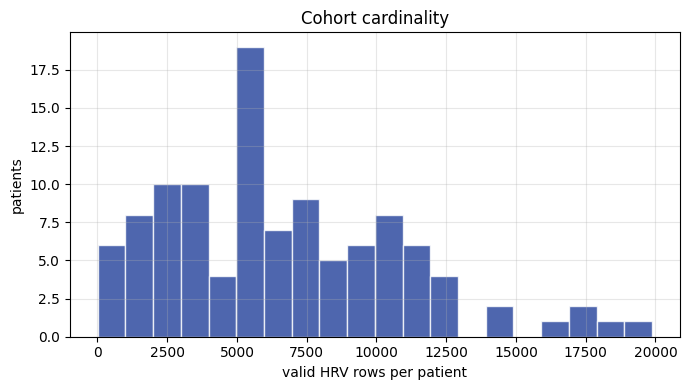

In [4]:
print('Patients           :', len(summary))
print('Total valid HRV    :', int(summary['n_valid'].sum()))
print('Rows/patient median:', int(summary['n_valid'].median()))
print('Rows/patient range :', int(summary['n_valid'].min()), '-', int(summary['n_valid'].max()))

fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(summary['n_valid'], bins=20, color='#22409A', alpha=0.8, edgecolor='white')
ax.set_xlabel('valid HRV rows per patient')
ax.set_ylabel('patients')
ax.set_title('Cohort cardinality')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 4. H1–H10 evidence across the cohort

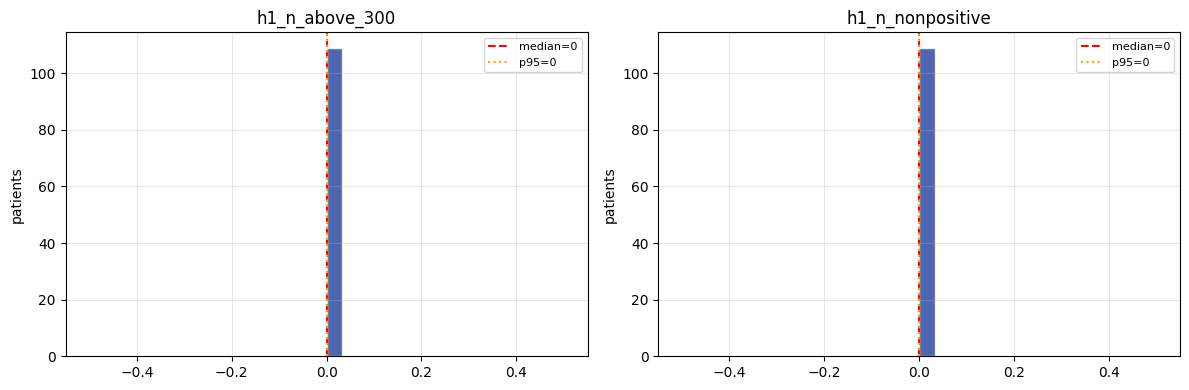

All-positive patients: 100%


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, col in zip(axes, ['h1_n_above_300', 'h1_n_nonpositive']):
    if col in summary.columns:
        v = summary[col].dropna()
        ax.hist(v, bins=min(30, max(len(v), 1)), color='#22409A', alpha=0.8, edgecolor='white')
        ax.axvline(v.median(), color='red', ls='--', lw=1.5, label=f'median={v.median():.0f}')
        ax.axvline(np.percentile(v, 95), color='orange', ls=':', lw=1.5, label=f'p95={np.percentile(v, 95):.0f}')
        ax.legend(fontsize=8)
    ax.set_title(col)
    ax.set_ylabel('patients')
    ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()
frac_pos = float(summary['h1_all_positive'].mean()) if 'h1_all_positive' in summary.columns else float('nan')
print('All-positive patients:', f'{frac_pos:.0%}')

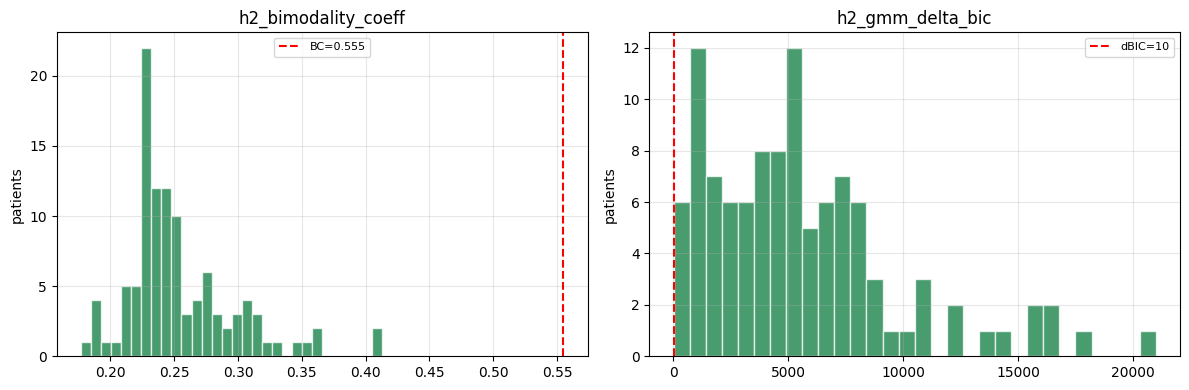

Bimodal by BC>0.555 : 0%
Bimodal by dBIC>10  : 99%


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, (col, thr, lab) in zip(axes, [('h2_bimodality_coeff', 0.555, 'BC=0.555'), ('h2_gmm_delta_bic', 10.0, 'dBIC=10')]):
    if col in summary.columns:
        v = summary[col].dropna()
        ax.hist(v, bins=min(30, max(len(v), 1)), color='#0B7B3E', alpha=0.75, edgecolor='white')
        ax.axvline(thr, color='red', ls='--', lw=1.5, label=lab)
        ax.legend(fontsize=8)
    ax.set_title(col)
    ax.set_ylabel('patients')
    ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()
bc = summary['h2_bimodality_coeff'].dropna() if 'h2_bimodality_coeff' in summary.columns else pd.Series(dtype=float)
bic = summary['h2_gmm_delta_bic'].dropna() if 'h2_gmm_delta_bic' in summary.columns else pd.Series(dtype=float)
if len(bc):
    print('Bimodal by BC>0.555 :', f'{(bc > 0.555).mean():.0%}')
if len(bic):
    print('Bimodal by dBIC>10  :', f'{(bic > 10).mean():.0%}')

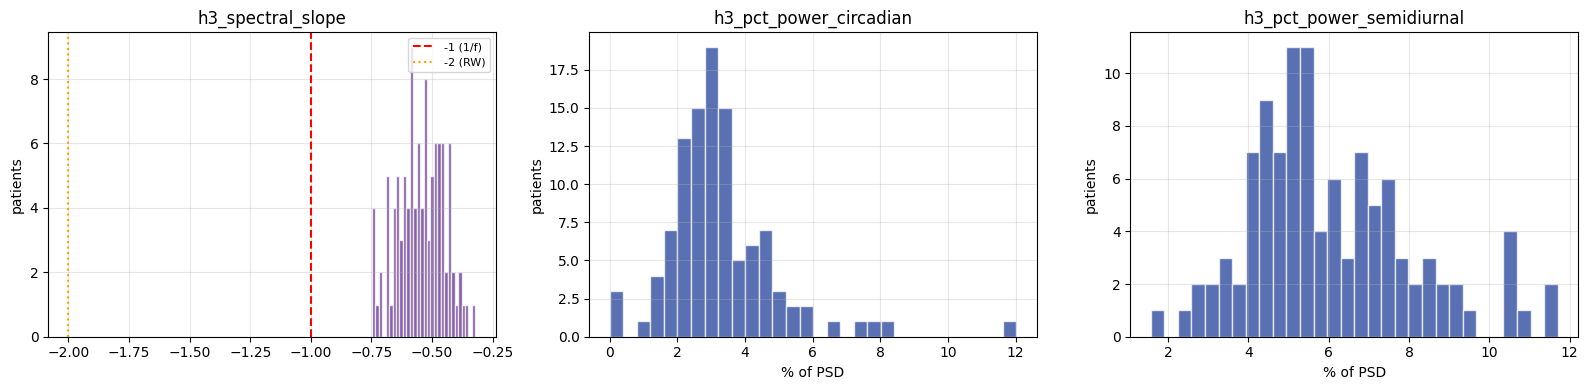

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
ax = axes[0]
if 'h3_spectral_slope' in summary.columns:
    v = summary['h3_spectral_slope'].dropna()
    ax.hist(v, bins=min(30, max(len(v), 1)), color='#5D2E8C', alpha=0.75, edgecolor='white')
    ax.axvline(-1, color='red', ls='--', lw=1.5, label='-1 (1/f)')
    ax.axvline(-2, color='orange', ls=':', lw=1.5, label='-2 (RW)')
    ax.legend(fontsize=8)
ax.set_title('h3_spectral_slope')
ax.set_ylabel('patients')
ax.grid(alpha=0.3)
for ax, col in zip(axes[1:], ['h3_pct_power_circadian', 'h3_pct_power_semidiurnal']):
    if col in summary.columns:
        v = summary[col].dropna()
        ax.hist(v, bins=min(30, max(len(v), 1)), color='#22409A', alpha=0.75, edgecolor='white')
    ax.set_title(col)
    ax.set_xlabel('% of PSD')
    ax.set_ylabel('patients')
    ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

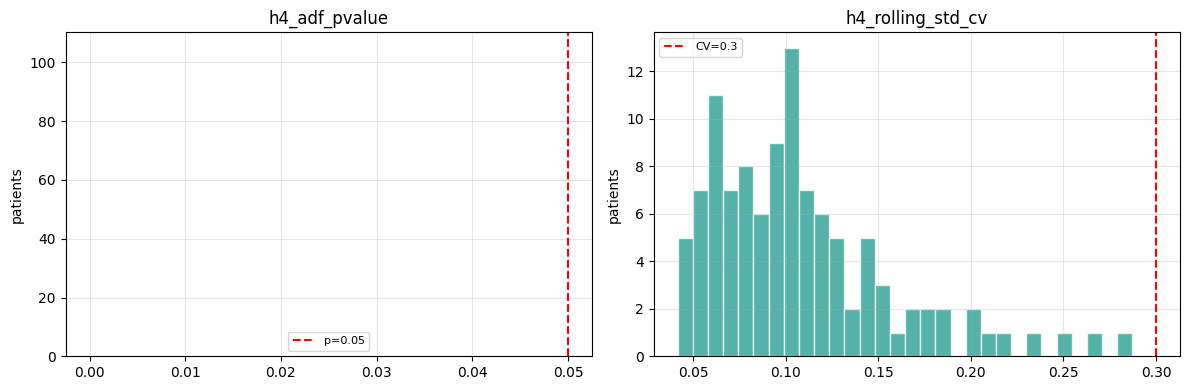

Non-stationary (ADF p>=0.05): 0%


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, (col, thr, lab) in zip(axes, [('h4_adf_pvalue', 0.05, 'p=0.05'), ('h4_rolling_std_cv', 0.3, 'CV=0.3')]):
    if col in summary.columns:
        v = summary[col].dropna()
        ax.hist(v, bins=min(30, max(len(v), 1)), color='#1B998B', alpha=0.75, edgecolor='white')
        ax.axvline(thr, color='red', ls='--', lw=1.5, label=lab)
        ax.legend(fontsize=8)
    ax.set_title(col)
    ax.set_ylabel('patients')
    ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()
adf = summary['h4_adf_pvalue'].dropna() if 'h4_adf_pvalue' in summary.columns else pd.Series(dtype=float)
if len(adf):
    print('Non-stationary (ADF p>=0.05):', f'{(adf >= 0.05).mean():.0%}')

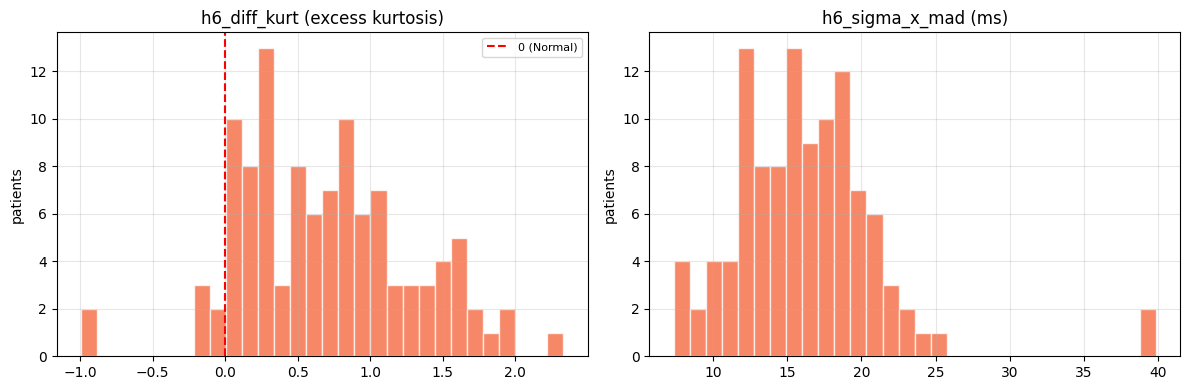

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
ax = axes[0]
if 'h6_diff_kurt' in summary.columns:
    v = summary['h6_diff_kurt'].dropna()
    ax.hist(v, bins=min(30, max(len(v), 1)), color='#F46036', alpha=0.75, edgecolor='white')
    ax.axvline(0, color='red', ls='--', lw=1.5, label='0 (Normal)')
    ax.legend(fontsize=8)
ax.set_title('h6_diff_kurt (excess kurtosis)')
ax.set_ylabel('patients')
ax.grid(alpha=0.3)
ax = axes[1]
if 'h6_sigma_x_mad' in summary.columns:
    v = summary['h6_sigma_x_mad'].dropna()
    ax.hist(v, bins=min(30, max(len(v), 1)), color='#F46036', alpha=0.75, edgecolor='white')
ax.set_title('h6_sigma_x_mad (ms)')
ax.set_ylabel('patients')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

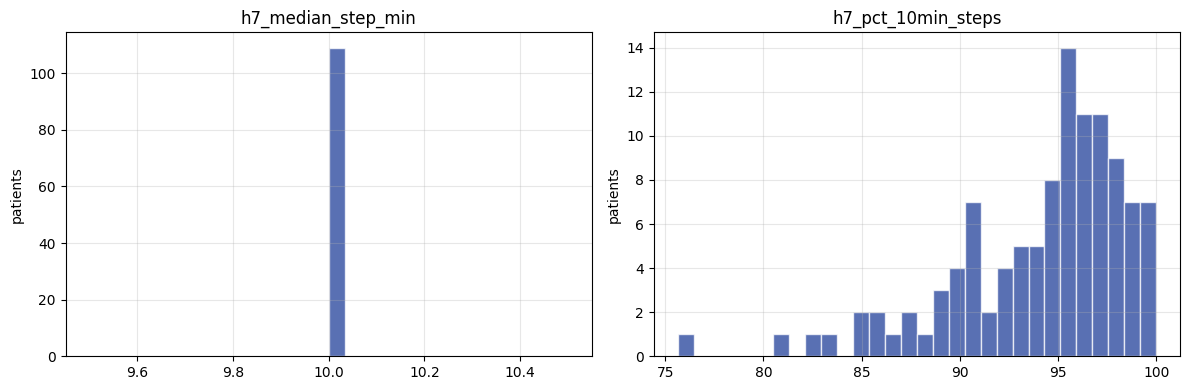

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, col in zip(axes, ['h7_median_step_min', 'h7_pct_10min_steps']):
    if col in summary.columns:
        v = summary[col].dropna()
        ax.hist(v, bins=min(30, max(len(v), 1)), color='#22409A', alpha=0.75, edgecolor='white')
    ax.set_title(col)
    ax.set_ylabel('patients')
    ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

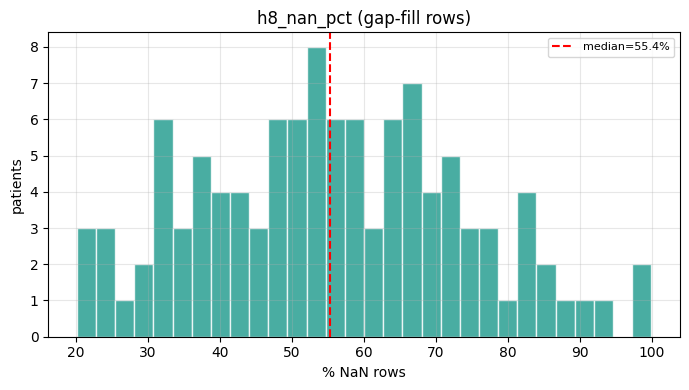

In [11]:
fig, ax = plt.subplots(figsize=(7, 4))
if 'h8_nan_pct' in summary.columns:
    v = summary['h8_nan_pct'].dropna()
    ax.hist(v, bins=min(30, max(len(v), 1)), color='#1B998B', alpha=0.8, edgecolor='white')
    ax.axvline(v.median(), color='red', ls='--', lw=1.5, label=f'median={v.median():.1f}%')
    ax.legend(fontsize=8)
ax.set_title('h8_nan_pct (gap-fill rows)')
ax.set_xlabel('% NaN rows')
ax.set_ylabel('patients')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

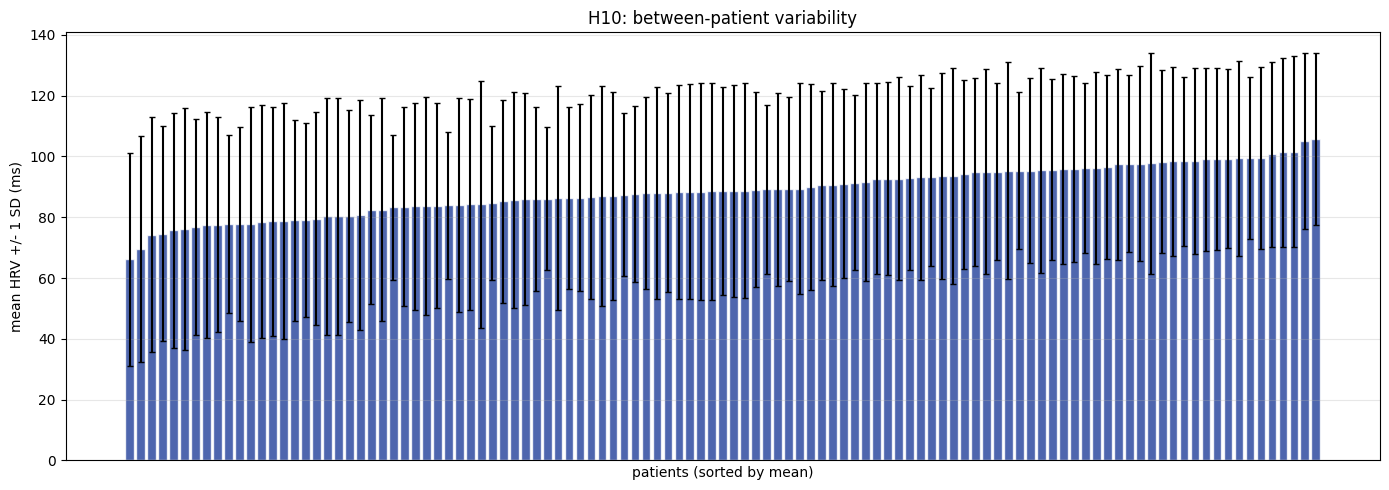

SD of patient means: 7.9 ms


In [12]:
if {'patient', 'mean', 'std'}.issubset(summary.columns):
    o = summary.dropna(subset=['mean']).sort_values('mean').reset_index(drop=True)
    x = np.arange(len(o))
    fig, ax = plt.subplots(figsize=(14, 5))
    ax.bar(x, o['mean'], yerr=o['std'], capsize=2, color='#22409A', alpha=0.8, edgecolor='white')
    ax.set_xticks([])
    ax.set_xlabel('patients (sorted by mean)')
    ax.set_ylabel('mean HRV +/- 1 SD (ms)')
    ax.set_title('H10: between-patient variability')
    ax.grid(alpha=0.3, axis='y')
    plt.tight_layout()
    plt.show()
    sdm = float(summary['mean'].std())
    print('SD of patient means:', f'{sdm:.1f}', 'ms')

## 5. H1–H10 global verdicts (proof)

In [13]:
def med(c):
    return float(summary[c].dropna().median()) if c in summary.columns and summary[c].notna().any() else float('nan')

n = len(summary)
frac_pos = float(summary['h1_all_positive'].mean()) if 'h1_all_positive' in summary.columns else float('nan')
above300 = med('h1_n_above_300')

bc = summary['h2_bimodality_coeff'].dropna() if 'h2_bimodality_coeff' in summary.columns else pd.Series(dtype=float)
bic = summary['h2_gmm_delta_bic'].dropna() if 'h2_gmm_delta_bic' in summary.columns else pd.Series(dtype=float)
bc_frac = float((bc > 0.555).mean()) if len(bc) else float('nan')
bic_frac = float((bic > 10).mean()) if len(bic) else float('nan')

slope = med('h3_spectral_slope')
circ = med('h3_pct_power_circadian')
semi = med('h3_pct_power_semidiurnal')

adf = summary['h4_adf_pvalue'].dropna() if 'h4_adf_pvalue' in summary.columns else pd.Series(dtype=float)
ns_frac = float((adf >= 0.05).mean()) if len(adf) else float('nan')
cv = med('h4_rolling_std_cv')

dk = med('h6_diff_kurt')
sx = med('h6_sigma_x_mad')
step = med('h7_median_step_min')
p10 = med('h7_pct_10min_steps')
nanp = med('h8_nan_pct')
sd_means = float(summary['mean'].dropna().std()) if 'mean' in summary.columns else float('nan')
med_pstd = med('std')

rows = [
    ('H1', 'Bounded & strictly positive', f'{frac_pos:.0%} patients all-positive; median {above300:.0f} rows >300 ms', 'CONFIRMED' if frac_pos == 1 else 'MOSTLY'),
    ('H2', 'Bimodal value distribution', f'{bc_frac:.0%} by BC>0.555; {bic_frac:.0%} by GMM dBIC>10', 'PRESENT' if bic_frac > 0.5 else ('WEAK' if bic_frac > 0.2 else 'ABSENT')),
    ('H3', 'Power-law (1/f) spectrum', f'median slope {slope:.2f}', '1/f-like' if -1.5 <= slope <= -0.5 else ('RW-like' if slope < -1.5 else 'flatter-than-1/f')),
    ('H4', 'Non-stationary baseline', f'{ns_frac:.0%} non-stationary (ADF p>=0.05); median rolling-CV {cv:.2f}', 'CONFIRMED' if ns_frac > 0.5 else 'MIXED'),
    ('H5', 'Circadian rhythm', f'median {circ:.1f}% PSD in 20-28h; {semi:.1f}% in 9-14h', 'PRESENT' if circ >= 5 else 'WEAK'),
    ('H6', 'Heavy-tailed noise', f'median first-diff excess kurtosis {dk:.2f}; sigma_x {sx:.1f} ms', 'HEAVY-TAILED' if dk > 0.5 else 'near-Gaussian'),
    ('H7', 'Sampling regularity', f'median step {step:.1f} min; {p10:.0f}% steps ~10 min', 'REGULAR' if p10 > 80 else 'IRREGULAR'),
    ('H8', 'Missingness (gaps)', f'median {nanp:.1f}% NaN gap-fill rows', 'PRESENT'),
    ('H9', 'Online operation', 'system requirement, not a data property', 'N/A'),
    ('H10', 'Between-patient variability', f'SD of patient means {sd_means:.1f} ms; median patient SD {med_pstd:.1f} ms', 'HIGH' if sd_means > 5 else 'LOW'),
]
htab = pd.DataFrame(rows, columns=['id', 'characteristic', 'cohort_evidence', 'verdict'])
htab.to_csv(OUT_DIR / 'h1_h10_global.csv', index=False)

NL = chr(10)
md = ['# H1-H10 derived from the processed HRV cohort', '', f'Cohort: {n} patients.', '', '| ID | Characteristic | Cohort evidence | Verdict |', '|---|---|---|---|']
for r in rows:
    md.append('| ' + ' | '.join(str(x) for x in r) + ' |')
(OUT_DIR / 'h1_h10_global.md').write_text(NL.join(md) + NL)
print('Saved h1_h10_global.csv and .md to', OUT_DIR)
htab

Saved h1_h10_global.csv and .md to /Users/jatindangi/Desktop/asthma-project-research/asthma-prediction/notebooks/outputs


,id,characteristic,cohort_evidence,verdict
0,H1,Bounded & strictly positive,100% patients all-positive; median 0 rows >300 ms,CONFIRMED
1,H2,Bimodal value distribution,0% by BC>0.555; 99% by GMM dBIC>10,PRESENT
2,H3,Power-law (1/f) spectrum,median slope -0.54,1/f-like
3,H4,Non-stationary baseline,0% non-stationary (ADF p>=0.05); median rollin...,MIXED
4,H5,Circadian rhythm,median 3.0% PSD in 20-28h; 5.5% in 9-14h,WEAK
5,H6,Heavy-tailed noise,median first-diff excess kurtosis 0.66; sigma_...,HEAVY-TAILED
6,H7,Sampling regularity,median step 10.0 min; 95% steps ~10 min,REGULAR
7,H8,Missingness (gaps),median 55.4% NaN gap-fill rows,PRESENT
8,H9,Online operation,"system requirement, not a data property",N/A
9,H10,Between-patient variability,SD of patient means 7.9 ms; median patient SD ...,HIGH


## 6. Provenance

In [14]:
import platform
import subprocess
from datetime import datetime

try:
    commit = subprocess.check_output(['git', 'rev-parse', 'HEAD'], cwd=str(REPO_ROOT)).decode().strip()
except Exception as e:
    commit = 'unavailable (' + str(e) + ')'

def _ver(mod):
    try:
        return __import__(mod).__version__
    except Exception:
        return 'not installed'

print('Run date      :', datetime.now().isoformat(timespec='seconds'))
print('Repo commit   :', commit)
print('Python        :', platform.python_version())
print('numpy         :', _ver('numpy'))
print('pandas        :', _ver('pandas'))
print('scipy         :', _ver('scipy'))
print('scikit-learn  :', _ver('sklearn'))
print('statsmodels   :', _ver('statsmodels'))

Run date      : 2026-06-10T00:20:18
Repo commit   : 201eae6d8aa2e5c753433a885a26d734e2770f7e
Python        : 3.10.4
numpy         : 1.26.4
pandas        : 2.1.1
scipy         : 1.15.3
scikit-learn  : 1.6.1
statsmodels   : 0.14.5
